In [1]:
import torch
from core.networks.unet import TemporalUnet_WCond
from core.networks.diffusion import GaussianDiffusionPB
from config.plane_test import PlaneTestConfig
import matplotlib.pyplot as plt
from core.datasets.plane_dataset import denormalize_data, get_data_stats

In [14]:
def load_model(checkpoint_path, device='cuda'):
    """Load the trained diffusion model from checkpoint"""
    config = PlaneTestConfig()
    
    # Initialize model components
    unet = TemporalUnet_WCond(
        horizon=config.horizon,
        transition_dim=config.transition_dim,
        network_config=config.network_config
    ).to(device)
    
    diffusion = GaussianDiffusionPB(
        model=unet,
        horizon=config.horizon,
        action_dim=config.action_dim,
        observation_dim=config.observation_dim,
        diff_config=config.diff_config
    ).to(device)
    
    # Load checkpoint with weights_only=False for older checkpoints
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    diffusion.load_state_dict(checkpoint['model_state_dict'])
    
    # Set to evaluation mode
    diffusion.eval()
    unet.eval()
    
    print(f"Model loaded from epoch {checkpoint['epoch']}")
    print(f"Best loss: {checkpoint['best_loss']:.6f}")
    
    return diffusion, config


def create_test_scenario(batch_size=1, device='cuda'):
    """Create a test scenario with start, goal, and obstacles"""
    # Example: simple scenario
    start_points = torch.tensor([[2, 1]], device=device, dtype=torch.float32)  # bottom-left
    goal_points = torch.tensor([[5, 7]], device=device, dtype=torch.float32)   # top-right
    
    # Create a simple obstacle map (8x8 grid)
    obstacle_map = torch.zeros(batch_size, 1, 8, 8, device=device, dtype=torch.float32)
    
    return start_points, goal_points, obstacle_map  # Add return statement


def generate_path(diffusion, start, goal, obstacles, use_ddim=True):
    """Generate a path using the diffusion model"""
    device = start.device
    batch_size = start.shape[0]
    
    # Prepare conditioning (start and goal constraints)
    cond = {
        0: start,                           # Condition at timestep 0 (start)
        diffusion.horizon - 1: goal        # Condition at final timestep (goal)
    }
    
    print(f"Generating path from {start[0].cpu().numpy()} to {goal[0].cpu().numpy()}")
    print(f"Using DDIM: {use_ddim}")
    
    with torch.no_grad():
        # Generate trajectory
        if use_ddim:
            trajectory = diffusion.ddim_p_sample_loop(
                shape=(batch_size, diffusion.horizon, diffusion.observation_dim),
                cond=cond,
                walls_loc=obstacles,
                verbose=True
            )
        else:
            trajectory = diffusion.p_sample_loop(
                shape=(batch_size, diffusion.horizon, diffusion.observation_dim),
                cond=cond,
                walls_loc=obstacles,
                verbose=True
            )
    
    return trajectory


def visualize_result(trajectory, start, goal, obstacles, save_path=None):
    """Visualize the generated trajectory"""
    # Convert to numpy
    traj_np = trajectory[0].cpu().numpy()  # Take first batch
    start_np = start[0].cpu().numpy()
    goal_np = goal[0].cpu().numpy()
    obs_np = obstacles[0, 0].cpu().numpy()  # Remove batch and channel dims
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.plot(traj_np[:, 0], traj_np[:, 1], 'b-', linewidth=2, label='Generated Path')
    ax1.plot(traj_np[:, 0], traj_np[:, 1], 'bo', markersize=3, alpha=0.6)
    ax1.plot(start_np[0], start_np[1], 'go', markersize=10, label='Start')
    ax1.plot(goal_np[0], goal_np[1], 'ro', markersize=10, label='Goal')
    ax1.set_xlim(0, 8)
    ax1.set_ylim(0, 8)
    ax1.set_title('Generated Trajectory')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Trajectory evolution over time
    ax2.plot(range(len(traj_np)), traj_np[:, 0], 'r-', label='X coordinate')
    ax2.plot(range(len(traj_np)), traj_np[:, 1], 'b-', label='Y coordinate')
    ax2.set_xlabel('Time step')
    ax2.set_ylabel('Position')
    ax2.set_title('Trajectory Components')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    plt.show()

[TemporalUnet_WCond] concept_drop_prob: 0.1
[TemporalUnet_WCond] time_dim: 32
[TemporalUnet_WCond] construct ViT1D as wall loc encoder
self.vit1d_config: {'image_size': 8, 'patch_size': 4, 'channels': 1, 'num_classes': 32, 'dim': 512, 'depth': 6, 'heads': 8, 'mlp_dim': 1024, 'dropout': 0.1, 'emb_dropout': 0.1}
[TemporalUnet_WCond] self.wallLoc_encoder <class 'core.networks.vit.ViT'>
[Unet down_times] 100000.0 
[Luo self.train_apply_condition] True
[Luo self.set_cond_noise_to_0] False
Model loaded from epoch 8200
Best loss: 0.004101
Generating path from [2. 1.] to [5. 7.]
Using DDIM: True
Before repeat:
x torch.Size([1, 32, 2])
t torch.Size([1])
walls_loc torch.Size([1, 1, 8, 8])
After repeat:
x_2 torch.Size([2, 32, 2])
t_2 torch.Size([2])
walls_loc_2 torch.Size([2, 1, 8, 8])
Before repeat:
x torch.Size([1, 32, 2])
t torch.Size([1])
walls_loc torch.Size([1, 1, 8, 8])
After repeat:
x_2 torch.Size([2, 32, 2])
t_2 torch.Size([2])
walls_loc_2 torch.Size([2, 1, 8, 8])
Before repeat:
x torch.

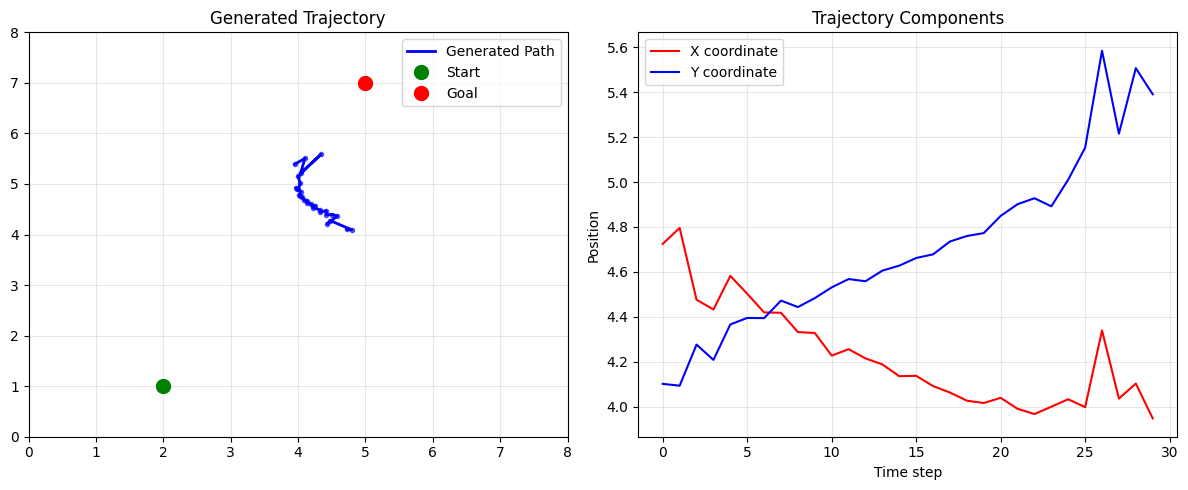

In [18]:
"""Main function to demonstrate model usage"""
# Configuration
ckt_path = 'checkpoints/checkpoint_epoch_8200.pt'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

diffusion, config = load_model(ckt_path, device)

# Create test scenario

start, goal, obstacles = create_test_scenario(batch_size=1, device=device)

# Generate path

trajectory = generate_path(diffusion, start, goal, obstacles, use_ddim=True)
device = trajectory.device  

stats = torch.load('dataset/train_stats.pt')
if not isinstance(stats['min'], torch.Tensor):
    stats['min'] = torch.tensor(stats['min'])
    stats['max'] = torch.tensor(stats['max'])

# 移动到同一个设备
stats['min'] = stats['min'].to(device)
stats['max'] = stats['max'].to(device)

de_trajectory = denormalize_data(trajectory[0, 1:31].unsqueeze(0), stats)

# Visualize results
print("Visualizing results...")
visualize_result(de_trajectory, start, goal, obstacles, save_path='generated_path.png')
